In [1]:
from __future__ import annotations

import json
import os
import sys
import time
from pathlib import Path

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None
    print('matplotlib is not installed; plotting helpers will be skipped.')
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from qwen3_ollama import _Scorer, score_application
from src.all_type_parser.all_type_parser import parse_and_save
from src.pool.build_pool import build_chunk_pool
from src.scoring.pipeline import (
    OVERALL_EXCLUDED_SECTIONS_BY_DOC_TYPE,
    SECTION_EXCLUDED_SUB_IDS_BY_DOC_TYPE,
    _aggregate_overall,
    _aggregate_section,
    _build_scored_section,
    _generate_json_with_parse_retry,
    _normalize_model_section_output,
    load_rubric,
)

CRITERIA_PATH = PROJECT_ROOT / 'criteria_points.json'
EXPERIMENT_ROOT = PROJECT_ROOT / 'experiments'
SAME_PDF_DIR = PROJECT_ROOT / 'data' / 'reliability'
RESULTS_DIR = EXPERIMENT_ROOT / 'results' / 'reliability_results'
PARSED_CACHE_DIR = RESULTS_DIR / 'parsed_cache'

DEFAULT_SAME_PDF_RUNS_PER_FILE = 3
WHOLE_JSON_BASELINE_MAX_TOKENS = int(os.environ.get('WHOLE_JSON_BASELINE_MAX_TOKENS', '32768'))
EXPERIMENT_OLLAMA_MODEL = 'qwen3.5:27b'  # Change here to switch the experiment model, e.g. 'qwen3.5:35b'

for path in [SAME_PDF_DIR, RESULTS_DIR, PARSED_CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SECTION_KEYS = [
    'general',
    'proposed_research',
    'training_development',
    'sites_support',
    'wpcc',
    'application_form',
]
SECTION_SCORE_COLUMNS = [f'{section_key}_score_100' for section_key in SECTION_KEYS]
RUN_SCORE_COLUMNS = ['overall_score_100', *SECTION_SCORE_COLUMNS]
RUN_DISPLAY_COLUMNS = ['pdf_name', 'run_idx', *RUN_SCORE_COLUMNS, 'avg_signal_score_0to5']
GROUP_RUN_DISPLAY_COLUMNS = ['group', *RUN_DISPLAY_COLUMNS]

print('Project root:', PROJECT_ROOT)
print('Same PDF dir:', SAME_PDF_DIR)
print('Results dir:', RESULTS_DIR)
print('Default same-pdf runs per file:', DEFAULT_SAME_PDF_RUNS_PER_FILE)
print('Whole-json baseline max tokens:', WHOLE_JSON_BASELINE_MAX_TOKENS)
print('Experiment Ollama model:', EXPERIMENT_OLLAMA_MODEL)


Project root: d:\msc_AI\SWE_group_project\nlp_grant_coursework
Same PDF dir: d:\msc_AI\SWE_group_project\nlp_grant_coursework\data\reliability
Results dir: d:\msc_AI\SWE_group_project\nlp_grant_coursework\experiments\results\reliability_results
Default same-pdf runs per file: 3
Whole-json baseline max tokens: 32768
Experiment Ollama model: qwen3.5:27b


In [2]:
def list_pdfs(folder: Path) -> list[Path]:
    return sorted([path for path in folder.glob('*.pdf') if path.is_file()])


def parse_pdf_cached(pdf_path: Path, *, reparse: bool = False) -> tuple[dict, Path]:
    json_path = PARSED_CACHE_DIR / f'{pdf_path.stem}.json'
    if reparse or not json_path.exists():
        parse_and_save(str(pdf_path), str(json_path))
    parsed = json.loads(json_path.read_text(encoding='utf-8'))
    return parsed, json_path


def make_experiment_scorer(model_name: str | None = None) -> _Scorer:
    return _Scorer(model_name=model_name or EXPERIMENT_OLLAMA_MODEL)


def score_pdf_once(
    pdf_path: Path,
    *,
    scorer: _Scorer,
    run_tag: str,
    reparse: bool = False,
) -> dict:
    parsed, parsed_json_path = parse_pdf_cached(pdf_path, reparse=reparse)
    artifact_dir = RESULTS_DIR / run_tag
    artifact_dir.mkdir(parents=True, exist_ok=True)
    result = score_application(
        parsed,
        CRITERIA_PATH,
        doc_id=f'{pdf_path.stem}_{run_tag}',
        scorer=scorer,
        artifacts_dir=artifact_dir,
    )
    result['source_pdf'] = str(pdf_path)
    result['parsed_json'] = str(parsed_json_path)
    out_path = artifact_dir / f'{pdf_path.stem}_{run_tag}_scored.json'
    out_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding='utf-8')
    result['result_json'] = str(out_path)
    return result


def compact_prompt_text(text: str, limit: int = 900) -> str:
    compact = ' '.join((text or '').split())
    if len(compact) <= limit:
        return compact
    return compact[:limit] + '...'


def build_baseline_chunk_index(pool_lookup: dict[str, dict[str, str]]) -> list[dict[str, str]]:
    return [
        {
            'chunk_id': chunk_id,
            'parser_section': meta.get('parser_section', ''),
            'source_path': meta.get('source_path', ''),
            'preview': compact_prompt_text(meta.get('text', '')),
        }
        for chunk_id, meta in pool_lookup.items()
    ]


def build_whole_json_baseline_schema(rubric_sections: list[dict], all_chunk_ids: list[str]) -> dict:
    chunk_id_item_schema = {'type': 'string'}
    if all_chunk_ids:
        chunk_id_item_schema['enum'] = all_chunk_ids

    section_properties = {}
    for section in rubric_sections:
        sub_properties = {}
        for sub in section['sub_criteria']:
            signal_properties = {
                signal['sid']: {'type': 'integer', 'enum': [0, 1, 2, 3, 4, 5]}
                for signal in sub['signals']
            }
            sub_properties[sub['sub_id']] = {
                'type': 'object',
                'properties': {
                    'signals': {
                        'type': 'object',
                        'properties': signal_properties,
                        'required': list(signal_properties),
                        'additionalProperties': False,
                    },
                    'used_chunk_ids': {
                        'type': 'array',
                        'items': chunk_id_item_schema,
                        'maxItems': 5,
                    },
                    'pros': {'type': 'string'},
                    'drawbacks': {'type': 'string'},
                },
                'required': ['signals', 'used_chunk_ids', 'pros', 'drawbacks'],
                'additionalProperties': False,
            }
        section_properties[section['section_key']] = {
            'type': 'object',
            'properties': sub_properties,
            'required': list(sub_properties),
            'additionalProperties': False,
        }
    return {
        'type': 'object',
        'properties': section_properties,
        'required': list(section_properties),
        'additionalProperties': False,
    }


def build_whole_json_baseline_messages(
    *,
    parsed_application: dict,
    rubric_sections: list[dict],
    pool_lookup: dict[str, dict[str, str]],
) -> list[dict[str, str]]:
    payload = {
        'task': 'one_shot_whole_parsed_json_baseline_scoring',
        'rules': [
            'Use the full parsed_application_json, criteria, and evidence_chunk_index only.',
            'Make exactly one direct score for every signal in every criterion.',
            'Score each signal as an integer from 0 to 5, where 0 means no evidence and 5 means excellent explicit evidence.',
            'Use used_chunk_ids only from evidence_chunk_index. If there is no relevant support, use an empty list and score weak or absent signals low.',
            'Pros should summarize the strongest support. Drawbacks should summarize missing, weak, inferred, or ambiguous support.',
        ],
        'criteria': rubric_sections,
        'evidence_chunk_index': build_baseline_chunk_index(pool_lookup),
        'parsed_application_json': parsed_application,
    }
    return [
        {
            'role': 'system',
            'content': (
                'You are a strict NIHR grant scoring baseline. You do not use staged retrieval, '
                'belief state, or multi-pass reasoning. Return JSON only and follow the schema exactly.'
            ),
        },
        {'role': 'user', 'content': json.dumps(payload, ensure_ascii=False, indent=2)},
    ]


def score_parsed_json_baseline_once(
    parsed_json_path: Path,
    *,
    scorer: _Scorer,
    run_tag: str = 'whole_json_baseline',
    source_pdf: Path | None = None,
) -> dict:
    parsed_json_path = Path(parsed_json_path)
    parsed = json.loads(parsed_json_path.read_text(encoding='utf-8'))
    doc_type = (parsed.get('doc_type') or '').lower()
    excluded_sections = OVERALL_EXCLUDED_SECTIONS_BY_DOC_TYPE.get(doc_type, set())
    excluded_sub_ids = SECTION_EXCLUDED_SUB_IDS_BY_DOC_TYPE.get(doc_type, set())

    rubric_sections = load_rubric(CRITERIA_PATH)
    pool_data = build_chunk_pool(parsed)
    pool_lookup = pool_data['pool_lookup']
    all_chunk_ids = list(pool_lookup)
    chunk_order = {chunk_id: idx for idx, chunk_id in enumerate(all_chunk_ids)}

    messages = build_whole_json_baseline_messages(
        parsed_application=parsed,
        rubric_sections=rubric_sections,
        pool_lookup=pool_lookup,
    )
    schema = build_whole_json_baseline_schema(rubric_sections, all_chunk_ids)
    raw_response, parsed_response, retry_count = _generate_json_with_parse_retry(
        scorer,
        messages,
        schema=schema,
        max_tokens=WHOLE_JSON_BASELINE_MAX_TOKENS,
        max_retries=0,
    )

    sections = []
    for rubric_section in rubric_sections:
        section_key = rubric_section['section_key']
        raw_section = parsed_response.get(section_key, {})
        if not isinstance(raw_section, dict):
            raw_section = {}
        normalized_section = _normalize_model_section_output(raw_section, rubric_section, all_chunk_ids)
        sections.append(_build_scored_section(
            rubric_section,
            normalized_section,
            chunk_order,
            excluded_sub_ids=excluded_sub_ids,
        ))

    features = {
        section['section_key']: _aggregate_section(section, pool_lookup)
        for section in sections
    }
    section_weights = {section['section_key']: section['weight'] for section in sections}
    artifact_dir = RESULTS_DIR / run_tag
    artifact_dir.mkdir(parents=True, exist_ok=True)
    raw_path = artifact_dir / f'{parsed_json_path.stem}_{run_tag}_raw.json'
    sections_path = artifact_dir / f'{parsed_json_path.stem}_{run_tag}_scored_sections.json'
    out_path = artifact_dir / f'{parsed_json_path.stem}_{run_tag}_scored.json'
    raw_path.write_text(raw_response, encoding='utf-8')
    sections_path.write_text(json.dumps(sections, ensure_ascii=False, indent=2), encoding='utf-8')

    result = {
        'doc_id': f'{parsed_json_path.stem}_{run_tag}',
        'run_info': {
            'ran_at_utc': pd.Timestamp.now(tz='UTC').isoformat(),
            'retrieval_method': 'whole_parsed_json_one_shot_baseline',
            'scorer_model': getattr(scorer, 'model_name', 'unknown'),
        },
        'pool_size': len(pool_lookup),
        'pool_lookup': pool_lookup,
        'section_chunk_ids': pool_data['section_chunk_ids'],
        'features': features,
        'overall': _aggregate_overall(features, section_weights, excluded_sections=excluded_sections),
        'source_pdf': str(source_pdf) if source_pdf else None,
        'parsed_json': str(parsed_json_path),
        'debug': {
            'scoring_contract_version': 'whole_parsed_json_baseline_v1',
            'doc_type': doc_type or None,
            'excluded_sections': sorted(excluded_sections),
            'excluded_sub_ids': sorted(excluded_sub_ids),
            'json_retry_events': [] if retry_count == 0 else [{'stage': 'whole_json_baseline', 'retry_count': retry_count}],
            'artifacts': {
                'raw_response': str(raw_path),
                'scored_sections': str(sections_path),
            },
        },
    }
    result['result_json'] = str(out_path)
    out_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding='utf-8')
    return result


def score_pdf_whole_json_baseline_once(
    pdf_path: Path,
    *,
    scorer: _Scorer,
    run_tag: str,
    reparse: bool = False,
) -> dict:
    _, parsed_json_path = parse_pdf_cached(pdf_path, reparse=reparse)
    return score_parsed_json_baseline_once(
        parsed_json_path,
        scorer=scorer,
        run_tag=run_tag,
        source_pdf=pdf_path,
    )


def run_whole_json_baseline_experiment(
    pdf_paths: list[Path],
    *,
    reparse: bool = False,
    model_name: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    assert pdf_paths, f'No PDF files found in {SAME_PDF_DIR}'
    scorer = make_experiment_scorer(model_name)
    rows = []
    for idx, pdf_path in enumerate(pdf_paths, start=1):
        run_tag = f'whole_json_baseline_{pdf_path.stem}'
        print(f'[whole_json_baseline {idx}/{len(pdf_paths)}] {pdf_path.name}')
        result = score_pdf_whole_json_baseline_once(
            pdf_path,
            scorer=scorer,
            run_tag=run_tag,
            reparse=reparse,
        )
        row = flatten_result_row(result, pdf_name=pdf_path.name, run_idx=1, group='whole_json_baseline')
        rows.append(row)
        print(f'  scores | {format_run_scores(row)}')
    df = pd.DataFrame(rows)
    summary = summarize_distribution(df, by='pdf_name')
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(RESULTS_DIR / f'whole_json_baseline_runs_{timestamp}.csv', index=False)
    summary.to_csv(RESULTS_DIR / f'whole_json_baseline_summary_{timestamp}.csv', index=False)
    return df, summary


def average_signal_score(result: dict) -> float:
    scores = []
    for section in result.get('features', {}).values():
        for criterion in section.get('sub_criteria', section.get('criteria', [])):
            for signal in criterion.get('signals', []):
                scores.append(float(signal.get('score_0to5_raw', signal.get('score', 0)) or 0))
    return round(sum(scores) / len(scores), 4) if scores else 0.0


def flatten_result_row(result: dict, *, pdf_name: str, run_idx: int | None, group: str | None) -> dict:
    overall = result.get('overall', {})
    row = {
        'pdf_name': pdf_name,
        'run_idx': run_idx,
        'group': group,
        'overall_score_100': float(overall.get('final_score_0to100', 0)),
        'overall_score_10': float(overall.get('score_10', 0)),
        'quality_score_100': float(overall.get('quality_score_0to100', 0)),
        'coverage_score_100': float(overall.get('coverage_score_0to100', 0)),
        'avg_signal_score_0to5': average_signal_score(result),
        'total_items': int(overall.get('total_items', 0)),
        'signal_count': int(overall.get('signal_count', 0)),
        'good_items': int(overall.get('good_items', 0)),
        'positive_items': int(overall.get('positive_items', 0)),
        'pool_size': int(result.get('pool_size', 0)),
        'source_pdf': result.get('source_pdf'),
        'parsed_json': result.get('parsed_json'),
        'result_json': result.get('result_json'),
    }
    features = result.get('features', {})
    for section_key in SECTION_KEYS:
        section = features.get(section_key, {})
        section_overall = section.get('overall', {})
        row[f'{section_key}_score_100'] = float(section_overall.get('final_score_0to100', 0))
        row[f'{section_key}_score_10'] = float(section_overall.get('score_10', 0))
        row[f'{section_key}_quality_score_100'] = float(section_overall.get('quality_score_0to100', 0))
        row[f'{section_key}_coverage_score_100'] = float(section_overall.get('coverage_score_0to100', 0))
        row[f'{section_key}_signal_count'] = int(section_overall.get('signal_count', 0))
    return row


def score_columns(df: pd.DataFrame) -> list[str]:
    return [col for col in RUN_SCORE_COLUMNS if col in df.columns]


def score_mean_std_columns(summary: pd.DataFrame) -> list[str]:
    id_cols = [col for col in ['pdf_name', 'group'] if col in summary.columns]
    metric_cols = []
    for metric in RUN_SCORE_COLUMNS:
        for suffix in ['mean', 'std']:
            col = f'{metric}_{suffix}'
            if col in summary.columns:
                metric_cols.append(col)
    if metric_cols:
        return id_cols + metric_cols
    return [col for col in ['metric', 'mean', 'std'] if col in summary.columns]


def format_run_scores(row: dict) -> str:
    parts = [f"overall={float(row.get('overall_score_100', 0)):.1f}"]
    for section_key in SECTION_KEYS:
        col = f'{section_key}_score_100'
        parts.append(f"{section_key}={float(row.get(col, 0)):.1f}")
    return ' | '.join(parts)


def summarize_numeric(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    summary = pd.DataFrame({
        'mean': df[columns].mean(),
        'std': df[columns].std(ddof=1),
        'var': df[columns].var(ddof=1),
        'min': df[columns].min(),
        'max': df[columns].max(),
        'median': df[columns].median(),
    }).reset_index().rename(columns={'index': 'metric'})
    return summary


def summarize_distribution(df: pd.DataFrame, *, by: str = 'pdf_name') -> pd.DataFrame:
    columns = score_columns(df)
    summary = df.groupby(by)[columns].agg(['count', 'mean', 'std', 'var', 'min', 'max', 'median'])
    summary.columns = ['_'.join(col).strip('_') for col in summary.columns.to_flat_index()]
    return summary.reset_index()


def plot_same_pdf(df: pd.DataFrame, pdf_name: str) -> None:
    if plt is None:
        print('matplotlib is not installed; skipping plot.')
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(df['run_idx'], df['overall_score_100'], marker='o')
    axes[0].set_title(f'Overall score by run: {pdf_name}')
    axes[0].set_xlabel('Run index')
    axes[0].set_ylabel('Score / 100')
    axes[0].grid(alpha=0.3)

    axes[1].boxplot(df['overall_score_100'], vert=True)
    axes[1].set_title('Overall score distribution')
    axes[1].set_ylabel('Score / 100')
    plt.tight_layout()
    plt.show()


def plot_same_pdf_distribution(df: pd.DataFrame) -> None:
    if plt is None:
        print('matplotlib is not installed; skipping plot.')
        return
    pdf_names = sorted(df['pdf_name'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(max(14, len(pdf_names) * 2.2), 4.5))
    for pdf_name, pdf_df in df.groupby('pdf_name'):
        axes[0].plot(pdf_df['run_idx'], pdf_df['overall_score_100'], marker='o', label=pdf_name)
    axes[0].set_title('Overall score by run')
    axes[0].set_xlabel('Run index')
    axes[0].set_ylabel('Score / 100')
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=8)

    grouped = [df.loc[df['pdf_name'] == pdf_name, 'overall_score_100'].tolist() for pdf_name in pdf_names]
    axes[1].boxplot(grouped, tick_labels=pdf_names)
    axes[1].set_title('Overall score distribution by PDF')
    axes[1].set_ylabel('Score / 100')
    axes[1].tick_params(axis='x', labelrotation=35)
    plt.tight_layout()
    plt.show()


def plot_group_compare(df: pd.DataFrame) -> None:
    if plt is None:
        print('matplotlib is not installed; skipping plot.')
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for group_name, group_df in df.groupby('group'):
        axes[0].hist(group_df['overall_score_100'], bins=min(10, max(3, len(group_df))), alpha=0.5, label=group_name)
    axes[0].set_title('Overall score distribution by group')
    axes[0].set_xlabel('Score / 100')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    grouped = [group_df['overall_score_100'].tolist() for _, group_df in sorted(df.groupby('group'))]
    labels = [group_name for group_name, _ in sorted(df.groupby('group'))]
    axes[1].boxplot(grouped, tick_labels=labels)
    axes[1].set_title('Overall score boxplot')
    axes[1].set_ylabel('Score / 100')
    plt.tight_layout()
    plt.show()


def optional_stat_tests(group_a_scores: pd.Series, group_b_scores: pd.Series) -> pd.DataFrame:
    rows = []
    try:
        from scipy.stats import ks_2samp, ttest_ind
        t_stat, t_p = ttest_ind(group_a_scores, group_b_scores, equal_var=False)
        ks_stat, ks_p = ks_2samp(group_a_scores, group_b_scores)
        rows.append({'test': 'welch_ttest', 'statistic': float(t_stat), 'p_value': float(t_p)})
        rows.append({'test': 'ks_2samp', 'statistic': float(ks_stat), 'p_value': float(ks_p)})
    except Exception as exc:
        rows.append({'test': 'scipy_unavailable', 'statistic': None, 'p_value': None, 'note': str(exc)})
    return pd.DataFrame(rows)


def run_same_pdf_experiment(
    pdf_path: Path,
    *,
    n_runs: int = DEFAULT_SAME_PDF_RUNS_PER_FILE,
    reparse_each_run: bool = False,
    sleep_seconds: float = 0.0,
    model_name: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    scorer = make_experiment_scorer(model_name)
    rows = []
    for run_idx in range(1, n_runs + 1):
        run_tag = f'same_pdf_{pdf_path.stem}_run_{run_idx:02d}'
        print(f'[{pdf_path.name}] run {run_idx}/{n_runs}')
        result = score_pdf_once(
            pdf_path,
            scorer=scorer,
            run_tag=run_tag,
            reparse=reparse_each_run,
        )
        row = flatten_result_row(result, pdf_name=pdf_path.name, run_idx=run_idx, group='same_pdf')
        rows.append(row)
        print(f'  scores | {format_run_scores(row)}')
        if sleep_seconds > 0:
            time.sleep(sleep_seconds)
    df = pd.DataFrame(rows)
    summary = summarize_numeric(df, score_columns(df))
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(RESULTS_DIR / f'same_pdf_{pdf_path.stem}_runs_{timestamp}.csv', index=False)
    summary.to_csv(RESULTS_DIR / f'same_pdf_{pdf_path.stem}_summary_{timestamp}.csv', index=False)
    return df, summary


def run_same_pdf_distribution_experiment(
    pdf_paths: list[Path],
    *,
    runs_per_pdf: int = DEFAULT_SAME_PDF_RUNS_PER_FILE,
    reparse_each_run: bool = False,
    sleep_seconds: float = 0.0,
    model_name: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    assert pdf_paths, f'No PDF files found in {SAME_PDF_DIR}'
    scorer = make_experiment_scorer(model_name)
    rows = []
    total_runs = len(pdf_paths) * runs_per_pdf
    completed = 0
    for pdf_path in pdf_paths:
        for run_idx in range(1, runs_per_pdf + 1):
            completed += 1
            run_tag = f'same_pdf_{pdf_path.stem}_run_{run_idx:02d}'
            print(f'[{completed}/{total_runs}] {pdf_path.name} run {run_idx}/{runs_per_pdf}')
            result = score_pdf_once(
                pdf_path,
                scorer=scorer,
                run_tag=run_tag,
                reparse=reparse_each_run,
            )
            row = flatten_result_row(result, pdf_name=pdf_path.name, run_idx=run_idx, group='same_pdf')
            rows.append(row)
            print(f'  scores | {format_run_scores(row)}')
            if sleep_seconds > 0:
                time.sleep(sleep_seconds)
    df = pd.DataFrame(rows)
    summary = summarize_distribution(df, by='pdf_name')
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(RESULTS_DIR / f'same_pdf_distribution_runs_{timestamp}.csv', index=False)
    summary.to_csv(RESULTS_DIR / f'same_pdf_distribution_summary_{timestamp}.csv', index=False)
    return df, summary


def run_group_compare_experiment(
    *,
    group_a_paths: list[Path],
    group_b_paths: list[Path],
    runs_per_pdf: int = 1,
    reparse_each_run: bool = False,
    model_name: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    scorer = make_experiment_scorer(model_name)
    rows = []
    for group_name, pdf_paths in [('group_a', group_a_paths), ('group_b', group_b_paths)]:
        for pdf_path in pdf_paths:
            for run_idx in range(1, runs_per_pdf + 1):
                run_tag = f'{group_name}_{pdf_path.stem}_run_{run_idx:02d}'
                print(f'[{group_name}] {pdf_path.name} run {run_idx}/{runs_per_pdf}')
                result = score_pdf_once(
                    pdf_path,
                    scorer=scorer,
                    run_tag=run_tag,
                    reparse=reparse_each_run,
                )
                row = flatten_result_row(result, pdf_name=pdf_path.name, run_idx=run_idx, group=group_name)
                rows.append(row)
                print(f'  scores | {format_run_scores(row)}')
    df = pd.DataFrame(rows)
    score_cols = score_columns(df)
    summary = df.groupby('group')[score_cols].agg(['count', 'mean', 'std', 'var', 'min', 'max', 'median'])
    summary.columns = ['_'.join(col).strip('_') for col in summary.columns.to_flat_index()]
    summary = summary.reset_index()
    tests = optional_stat_tests(
        df.loc[df['group'] == 'group_a', 'overall_score_100'],
        df.loc[df['group'] == 'group_b', 'overall_score_100'],
    )
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(RESULTS_DIR / f'group_compare_runs_{timestamp}.csv', index=False)
    summary.to_csv(RESULTS_DIR / f'group_compare_summary_{timestamp}.csv')
    tests.to_csv(RESULTS_DIR / f'group_compare_tests_{timestamp}.csv', index=False)
    return df, summary, tests


[qwen3_ollama] using http://127.0.0.1:11434 model=qwen3.5:27b
[1/30] IC00001_DF_Doctoral.pdf run 1/3
  scores | overall=89.7 | general=87.0 | proposed_research=92.1 | training_development=96.7 | sites_support=76.2 | wpcc=87.8 | application_form=98.3
[2/30] IC00001_DF_Doctoral.pdf run 2/3
  scores | overall=89.5 | general=92.0 | proposed_research=95.0 | training_development=86.7 | sites_support=82.5 | wpcc=88.9 | application_form=91.7
[3/30] IC00001_DF_Doctoral.pdf run 3/3
  scores | overall=88.8 | general=87.0 | proposed_research=93.3 | training_development=91.7 | sites_support=91.2 | wpcc=77.8 | application_form=91.7
[4/30] IC00029_RfPB.pdf run 1/3
  scores | overall=81.6 | general=73.3 | proposed_research=97.1 | training_development=23.3 | sites_support=72.5 | wpcc=76.7 | application_form=88.3
[5/30] IC00029_RfPB.pdf run 2/3
  scores | overall=79.2 | general=71.1 | proposed_research=90.4 | training_development=28.3 | sites_support=68.8 | wpcc=82.2 | application_form=83.3
[6/30] IC000

,pdf_name,run_idx,overall_score_100,general_score_100,proposed_research_score_100,training_development_score_100,sites_support_score_100,wpcc_score_100,application_form_score_100,avg_signal_score_0to5
0,IC00001_DF_Doctoral.pdf,1,89.7,87.0,92.1,96.7,76.2,87.8,98.3,4.3482
1,IC00001_DF_Doctoral.pdf,2,89.5,92.0,95.0,86.7,82.5,88.9,91.7,4.5089
2,IC00001_DF_Doctoral.pdf,3,88.8,87.0,93.3,91.7,91.2,77.8,91.7,4.3125
3,IC00029_RfPB.pdf,1,81.6,73.3,97.1,23.3,72.5,76.7,88.3,3.7679
4,IC00029_RfPB.pdf,2,79.2,71.1,90.4,28.3,68.8,82.2,83.3,3.5357
5,IC00029_RfPB.pdf,3,83.7,78.3,92.5,11.7,78.8,85.5,83.3,3.6071
6,IC00087_DCAF_Doctoral.pdf,1,90.6,87.0,96.5,86.7,95.0,90.0,88.3,4.5268
7,IC00087_DCAF_Doctoral.pdf,2,90.0,94.0,92.5,85.0,90.0,93.3,85.0,4.5536
8,IC00087_DCAF_Doctoral.pdf,3,86.3,84.0,92.5,80.0,86.2,85.5,89.4,4.3304
9,IC00091_AF_Postdoctoral.pdf,1,88.2,90.0,95.0,100.0,80.0,74.4,90.0,4.4196


,pdf_name,overall_score_100_mean,overall_score_100_std,general_score_100_mean,general_score_100_std,proposed_research_score_100_mean,proposed_research_score_100_std,training_development_score_100_mean,training_development_score_100_std,sites_support_score_100_mean,sites_support_score_100_std,wpcc_score_100_mean,wpcc_score_100_std,application_form_score_100_mean,application_form_score_100_std
0,IC00001_DF_Doctoral.pdf,89.333333,0.472582,88.666667,2.886751,93.466667,1.457166,91.700000,5.000000,83.300000,7.531932,84.833333,6.115826,93.900000,3.810512
1,IC00029_RfPB.pdf,81.500000,2.251666,74.233333,3.689625,93.333333,3.426855,21.100000,8.515868,73.366667,5.056020,81.466667,4.445597,84.966667,2.886751
2,IC00087_DCAF_Doctoral.pdf,88.966667,2.328805,88.333333,5.131601,93.833333,2.309401,83.900000,3.482815,90.400000,4.413615,89.600000,3.915354,87.566667,2.289833
3,IC00091_AF_Postdoctoral.pdf,88.233333,1.550269,89.000000,1.732051,93.333333,2.886751,97.766667,3.868247,82.500000,6.614378,74.033333,1.680278,92.800000,3.482815
4,IC00157_ACAF_Postdoctoral.pdf,80.433333,4.701418,91.666667,1.527525,86.366667,1.721434,88.333333,9.258690,82.100000,8.872993,45.933333,10.276835,88.333333,1.650253
5,IC00159_RfPB.pdf,78.333333,0.115470,74.433333,1.962991,90.866667,0.577350,0.000000,0.000000,69.566667,4.007909,72.966667,2.345918,83.866667,0.981495
6,IC00458_RfPB.pdf,53.000000,1.153256,10.566667,2.419366,91.066667,1.443376,0.000000,0.000000,36.266667,3.288363,88.500000,2.821347,91.633333,5.773503
7,IC00464_after.pdf,83.533333,1.301281,72.133333,2.379776,92.933333,1.501111,59.433333,4.178915,94.166667,5.204165,94.066667,2.345918,88.333333,4.384442
8,IC00494_after.pdf,65.033333,0.950438,19.200000,1.558846,93.566667,1.443376,31.666667,1.650253,68.766667,1.250333,82.566667,3.360556,94.266667,3.536005
9,IC00527_after.pdf,82.500000,1.900000,76.900000,10.045895,88.533333,3.074627,77.766667,3.868247,78.766667,4.479211,80.766667,4.221769,92.200000,6.717887


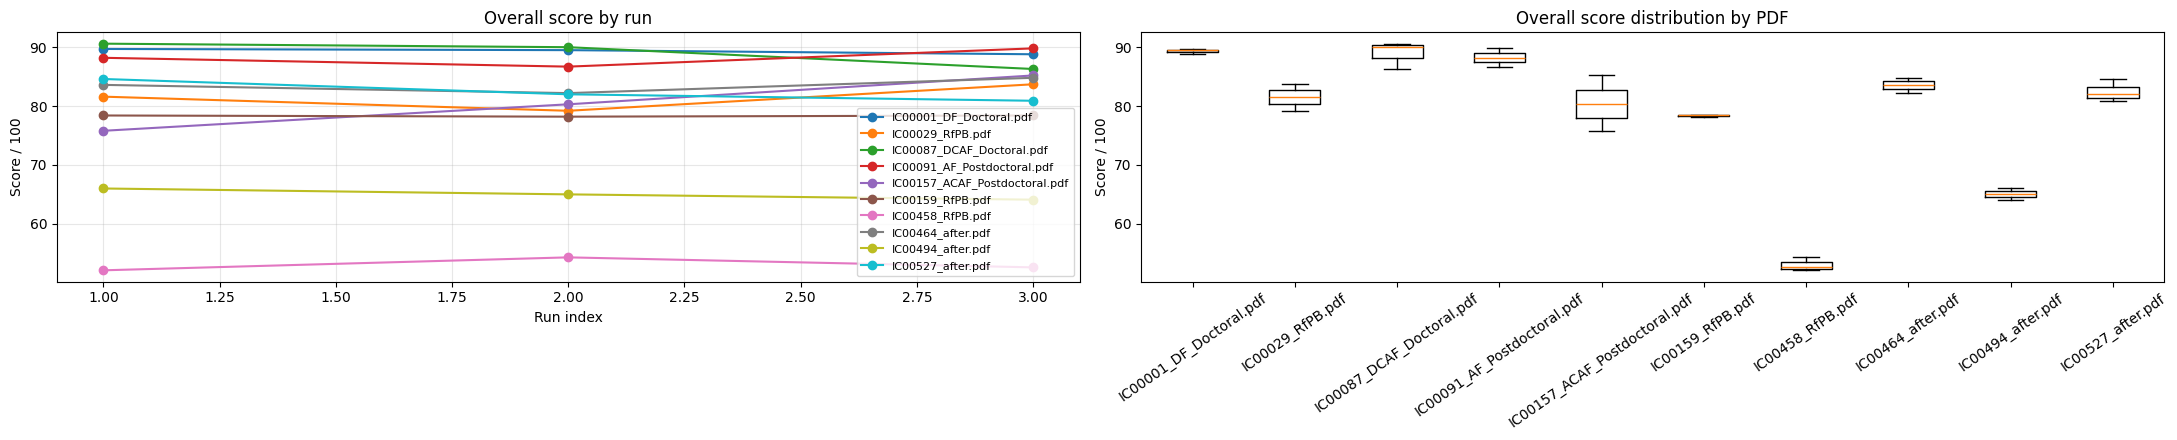

In [14]:
same_pdf_files = list_pdfs(SAME_PDF_DIR)
assert same_pdf_files, f'Please place at least 1 PDF in {SAME_PDF_DIR}.'

same_pdf_df, same_pdf_summary = run_same_pdf_distribution_experiment(
    same_pdf_files,
    runs_per_pdf=DEFAULT_SAME_PDF_RUNS_PER_FILE,
    reparse_each_run=False,
    sleep_seconds=0.0,
)

display(same_pdf_df[RUN_DISPLAY_COLUMNS])
display(same_pdf_summary[score_mean_std_columns(same_pdf_summary)])
plot_same_pdf_distribution(same_pdf_df)


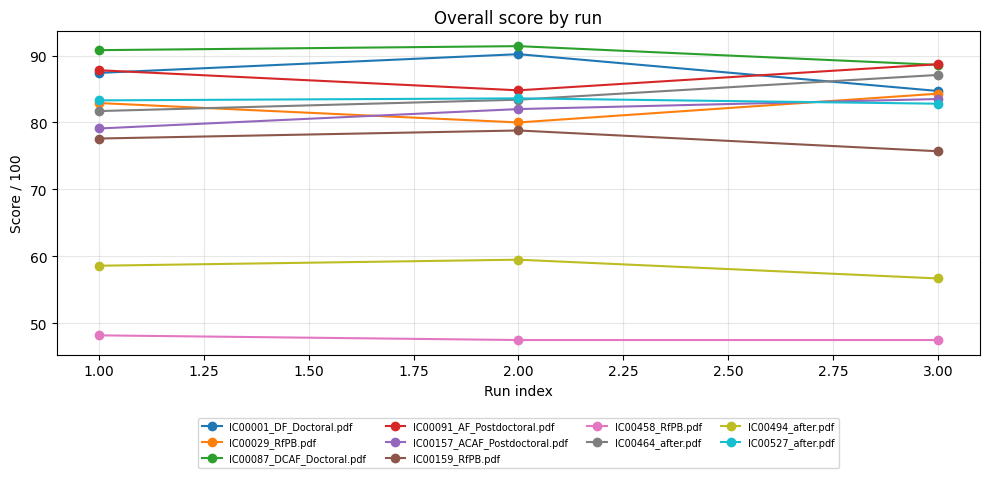

In [4]:
# ── Load saved results & Plot 1: Overall score by run (legend at bottom) ─────
csv_path = RESULTS_DIR / 'same_pdf_distribution_runs_20260421_140159.csv'
same_pdf_df_loaded = pd.read_csv(csv_path)

if plt is not None:
    pdf_names = sorted(same_pdf_df_loaded['pdf_name'].unique())
    fig, ax = plt.subplots(figsize=(10, 5))
    for pdf_name, pdf_df in same_pdf_df_loaded.groupby('pdf_name'):
        ax.plot(pdf_df['run_idx'], pdf_df['overall_score_100'], marker='o', label=pdf_name)
    ax.set_title('Overall score by run')
    ax.set_xlabel('Run index')
    ax.set_ylabel('Score / 100')
    ax.grid(alpha=0.3)
    ax.legend(
        fontsize=7,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.18),
        ncol=min(4, len(pdf_names)),
        frameon=True,
    )
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'reliability_score_by_run.png', dpi=150, bbox_inches='tight')
    plt.show()


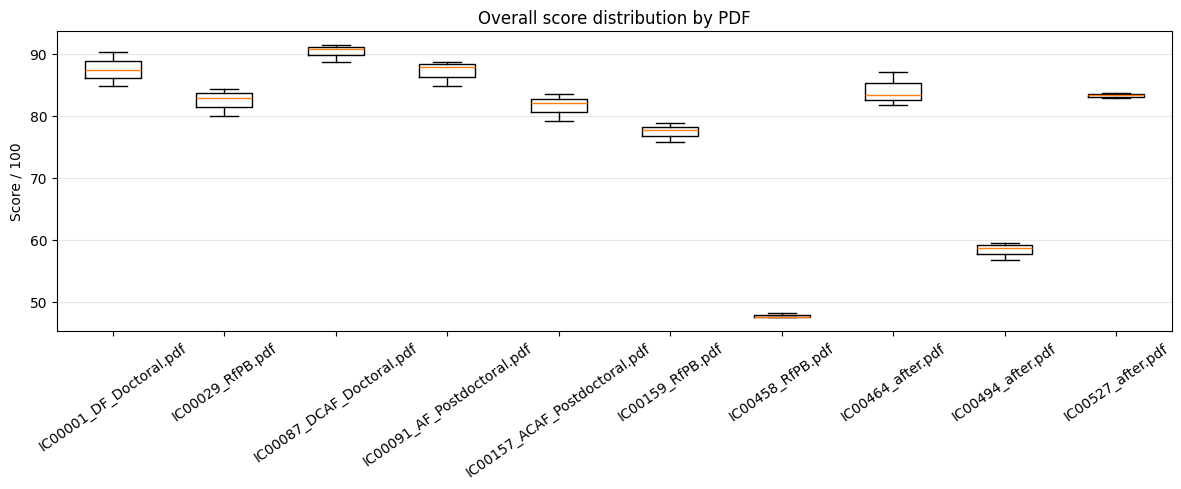

In [5]:
# ── Plot 2: Overall score distribution by PDF (box plot) ─────────────────────
if plt is not None:
    pdf_names = sorted(same_pdf_df_loaded['pdf_name'].unique())
    grouped = [
        same_pdf_df_loaded.loc[same_pdf_df_loaded['pdf_name'] == pdf_name, 'overall_score_100'].tolist()
        for pdf_name in pdf_names
    ]
    fig, ax = plt.subplots(figsize=(max(10, len(pdf_names) * 1.2), 5))
    ax.boxplot(grouped, tick_labels=pdf_names)
    ax.set_title('Overall score distribution by PDF')
    ax.set_ylabel('Score / 100')
    ax.tick_params(axis='x', labelrotation=35)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'reliability_score_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()


In [2]:
import sys
!{sys.executable} -m pip install --ignore-installed -r /workspace/nlp_grant_coursework/requirements.txt

  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached transformers-5.6.2-py3-none-any.whl.metadata (33 kB)
  Using cached spacy-3.8.14-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (28 kB)
  Using cached pdfplumber-0.11.9-py3-none-any.whl.metadata (43 kB)
  Using cached pymupdf-1.27.2.3-cp310-abi3-manylinux_2_28_x86_64.whl.metadata (24 kB)
  Using cached python_docx-1.2.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached pdf2image-1.17.0-py3-none-any.whl.metadata (6.2 kB)
  Using cached pytesseract-0.3.13-py3-none-any.whl.metadata (11 kB)
  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl

In [7]:
!pip install matplotlib

  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 100.2 MB/s  0:00:00
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (5.0 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]


## Baseline Experiment — Single LLM call for direct scoring (sub-criterion level)

**Purpose**: Compare against the multi-stage pipeline scoring above to evaluate the pipeline's gain and stability over the simplest baseline.

**Method**:
- No preprocessing (no chunking, no Stage 1 evidence retrieval, no per-section calls)
- Feed the full parsed JSON + all sub-criteria definitions in `criteria_points.json` (with each signal text as reference) to the LLM in a single call
- The LLM directly outputs a 0–10 score for **each sub-criterion** (signals are reference only, not scored individually)
- Aggregation matches the pipeline: sub-criterion (0–10) → section (0–100) → overall (0–100)
- Run each PDF 3 times to observe scoring stability

In [10]:
# ── Baseline helpers ─────────────────────────────────────────────────────────
BASELINE_NUM_CTX = 49152   # Ollama context window (tokens). Increase if scores are all 0.
BASELINE_MAX_TOKENS = 1024


class _BaselineScorer:
    """Thin wrapper around Ollama that injects num_ctx into every request."""

    def __init__(self, model_name: str = EXPERIMENT_OLLAMA_MODEL, num_ctx: int = BASELINE_NUM_CTX):
        from qwen3_ollama import OLLAMA_HOST, OLLAMA_TIMEOUT
        import requests as _requests
        self.model_name = model_name
        self.num_ctx = num_ctx
        self._host = OLLAMA_HOST
        self._timeout = OLLAMA_TIMEOUT
        self._requests = _requests
        self.last_response_body = None
        print(f'[baseline] model={model_name}  num_ctx={num_ctx}', flush=True)

    def generate_json(self, messages: list, *, schema: dict, max_tokens: int) -> str:
        import re as _re
        payload = {
            'model': self.model_name,
            'messages': messages,
            'stream': False,
            'format': schema,
            'options': {
                'temperature': 1,
                'top_p': 0.9,
                'num_predict': max_tokens,
                'num_ctx': self.num_ctx,
            },
            'think': False,
        }
        try:
            resp = self._requests.post(
                f'{self._host}/api/chat', json=payload, timeout=self._timeout,
            )
        except self._requests.exceptions.ConnectionError as exc:
            raise RuntimeError(f'Could not connect to Ollama at {self._host}.') from exc
        except self._requests.exceptions.Timeout as exc:
            raise RuntimeError('Timed out waiting for Ollama.') from exc
        resp.raise_for_status()
        body = resp.json()
        self.last_response_body = body
        message = body.get('message') or {}
        content = _re.sub(
            r'<think>.*?</think>\s*', '', message.get('content') or '', flags=_re.DOTALL,
        ).strip()
        first, last = content.find('{'), content.rfind('}')
        return content[first:last + 1] if first != -1 and last > first else content


def _build_baseline_sub_schema(rubric_sections: list) -> dict:
    """JSON schema: sub_criterion_id → float 0-10. Signals not enforced."""
    properties = {
        sub['sub_id']: {'type': 'number', 'minimum': 0, 'maximum': 10}
        for sec in rubric_sections
        for sub in sec['sub_criteria']
    }
    return {
        'type': 'object',
        'properties': properties,
        'required': list(properties.keys()),
        'additionalProperties': False,
    }


def _format_criteria_for_prompt(rubric_sections: list) -> str:
    """Format all sub-criteria and their signals as readable reference text."""
    lines = []
    for section in rubric_sections:
        lines.append(f"\n=== {section['human_name']} ===")
        for sub in section['sub_criteria']:
            lines.append(f"  [{sub['sub_id']}] {sub['name']}")
            lines.append(f"  Definition: {sub['definition']}")
            for sig in sub['signals']:
                lines.append(f"    - {sig['text']}")
    return '\n'.join(lines)


def _build_baseline_messages(parsed_app: dict, rubric_sections: list) -> list:
    criteria_text = _format_criteria_for_prompt(rubric_sections)
    all_sub_ids = [
        sub['sub_id']
        for sec in rubric_sections
        for sub in sec['sub_criteria']
    ]
    if_applicable_subs = [
        sub['sub_id']
        for sec in rubric_sections
        for sub in sec['sub_criteria']
        if 'if applicable' in f"{sub.get('name', '')} {sub.get('definition', '')}".lower()
    ]
    system = (
        'You are an expert grant application reviewer.\n'
        'Score the grant application according to the scoring rubric below.\n'
        'For each sub-criterion, assign a score from 0 to 10.\n'
        'Use the signals listed under each sub-criterion as reference '
        'when deciding the score — do NOT score each signal individually.\n'
        'Sub-criteria marked as "if applicable" that do not apply to this '
        'application should receive a score of -1 to indicate N/A.\n'
        'Return JSON only.\n'
        'Structure: top-level keys are sub-criterion IDs, values are numbers (0-10, or -1 for N/A).\n'
        f'Required keys: {all_sub_ids}\n'
        f'Potentially N/A sub-criteria: {if_applicable_subs}'
    )
    user = (
        'SCORING RUBRIC (signals are reference only — score at sub-criterion level):\n'
        + criteria_text
        + '\n\nGRANT APPLICATION:\n'
        + json.dumps(parsed_app, ensure_ascii=False, indent=2)
        + '\n\nReturn a JSON object mapping each sub-criterion ID to its 0-10 score '
        '(or -1 if not applicable).'
    )
    return [
        {'role': 'system', 'content': system},
        {'role': 'user', 'content': user},
    ]


def _aggregate_baseline(raw_scores: dict, rubric_sections: list, doc_type: str = '') -> tuple:
    """
    raw_scores: {sub_id: float(0-10)}, -1 means N/A (excluded from average).
    Aggregation mirrors pipeline: sub score_10 (weighted) -> section -> overall.
    """
    dt = doc_type.lower()
    excluded_sections = OVERALL_EXCLUDED_SECTIONS_BY_DOC_TYPE.get(dt, set())
    excluded_sub_ids = SECTION_EXCLUDED_SUB_IDS_BY_DOC_TYPE.get(dt, set())

    features = {}
    all_sub_scores = []

    for section in rubric_sections:
        section_key = section['section_key']
        sub_results = []

        for sub in section['sub_criteria']:
            sub_id = sub['sub_id']
            raw_val = raw_scores.get(sub_id, 0)
            is_na = isinstance(raw_val, (int, float)) and raw_val < 0
            score_10 = 0.0 if is_na else round(max(0.0, min(10.0, float(raw_val))), 2)
            is_doc_excluded = sub_id in excluded_sub_ids
            counts = not is_na and not is_doc_excluded
            sub_results.append({
                'sub_id': sub_id,
                'name': sub['name'],
                'weight': sub['weight'],
                'score_10': score_10,
                'is_na': is_na,
                'counts_toward_section_average': counts,
            })
            if counts:
                all_sub_scores.append(score_10)

        scored = [s for s in sub_results if s['counts_toward_section_average']] or sub_results
        total_w = sum(s['weight'] for s in scored) or 1.0
        section_score_10 = round(
            sum(s['score_10'] * s['weight'] for s in scored) / total_w, 2
        )
        positive_items = sum(1 for s in scored if s['score_10'] > 0)

        features[section_key] = {
            'score_10': section_score_10,
            'weight': section['weight'],
            'sub_criteria': sub_results,
            'overall': {
                'score_10': section_score_10,
                'final_score_0to100': round(section_score_10 * 10, 2),
                'positive_items': positive_items,
                'scored_items': len(scored),
                'total_items': len(sub_results),
                'signal_count': sum(len(sub['signals']) for sub in section['sub_criteria']),
            },
        }

    scoring_features = {
        k: v for k, v in features.items() if k not in excluded_sections
    } or features
    section_weights = {k: v['weight'] for k, v in features.items()}
    total_w = sum(section_weights.get(k, 1.0) for k in scoring_features) or 1.0
    overall_10 = round(
        sum(features[k]['score_10'] * section_weights.get(k, 1.0) for k in scoring_features) / total_w, 2
    )
    overall = {
        'score_10': overall_10,
        'final_score_0to100': round(overall_10 * 10, 2),
    }
    avg_sub_as_signal = round(sum(all_sub_scores) / len(all_sub_scores) / 2, 4) if all_sub_scores else 0.0
    return features, overall, avg_sub_as_signal


def baseline_score_pdf_once(
    pdf_path: Path,
    *,
    scorer,
    run_tag: str,
    reparse: bool = False,
    criteria_path: Path = CRITERIA_PATH,
) -> dict:
    """parse (cached) -> single LLM call (sub-criterion scores) -> aggregation."""
    parsed, parsed_json_path = parse_pdf_cached(pdf_path, reparse=reparse)
    rubric_sections = load_rubric(criteria_path)
    doc_type = (parsed.get('doc_type') or '').lower()

    messages = _build_baseline_messages(parsed, rubric_sections)
    schema = _build_baseline_sub_schema(rubric_sections)
    raw = scorer.generate_json(messages, schema=schema, max_tokens=BASELINE_MAX_TOKENS)

    try:
        raw_scores = json.loads(raw)
    except json.JSONDecodeError:
        import re as _re
        m = _re.search(r'\{.*\}', raw, _re.DOTALL)
        raw_scores = json.loads(m.group()) if m else {}

    features, overall, avg_sub = _aggregate_baseline(raw_scores, rubric_sections, doc_type)

    artifact_dir = RESULTS_DIR / run_tag
    artifact_dir.mkdir(parents=True, exist_ok=True)
    out_path = artifact_dir / f'{pdf_path.stem}_{run_tag}_baseline.json'
    result = {
        'doc_id': f'{pdf_path.stem}_{run_tag}',
        'source_pdf': str(pdf_path),
        'parsed_json': str(parsed_json_path),
        'features': features,
        'overall': overall,
        'avg_signal_score_0to5': avg_sub,
        'raw_sub_scores': raw_scores,
        'raw_llm_response': raw,
    }
    out_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding='utf-8')
    result['result_json'] = str(out_path)
    return result


def flatten_baseline_row(result: dict, *, pdf_name: str, run_idx: int) -> dict:
    overall = result.get('overall', {})
    features = result.get('features', {})
    row = {
        'pdf_name': pdf_name,
        'run_idx': run_idx,
        'overall_score_100': float(overall.get('final_score_0to100', 0)),
        'avg_signal_score_0to5': float(result.get('avg_signal_score_0to5', 0)),
        'source_pdf': result.get('source_pdf'),
        'result_json': result.get('result_json'),
    }
    for key in SECTION_KEYS:
        sec = features.get(key, {})
        row[f'{key}_score_100'] = float(sec.get('overall', {}).get('final_score_0to100', 0))
    return row


def run_baseline_experiment(
    pdf_paths: list,
    *,
    runs_per_pdf: int = DEFAULT_SAME_PDF_RUNS_PER_FILE,
    reparse_each_run: bool = False,
    model_name: str | None = None,
) -> tuple:
    """Run baseline on PDFs in the same_pdf directory, runs_per_pdf times each."""
    assert pdf_paths, 'No PDF files found.'
    scorer = _BaselineScorer(model_name=model_name or EXPERIMENT_OLLAMA_MODEL)
    rows = []
    total = len(pdf_paths) * runs_per_pdf
    completed = 0
    for pdf_path in pdf_paths:
        for run_idx in range(1, runs_per_pdf + 1):
            completed += 1
            run_tag = f'baseline_{pdf_path.stem}_run_{run_idx:02d}'
            print(f'[baseline {completed}/{total}] {pdf_path.name} run {run_idx}/{runs_per_pdf}')
            result = baseline_score_pdf_once(
                pdf_path, scorer=scorer, run_tag=run_tag, reparse=reparse_each_run,
            )
            row = flatten_baseline_row(result, pdf_name=pdf_path.name, run_idx=run_idx)
            rows.append(row)
            section_parts = ' | '.join(
                f'{k}={row[f"{k}_score_100"]:.1f}' for k in SECTION_KEYS
            )
            print(f"  overall={row['overall_score_100']:.1f} | avg_sub(0-5)={row['avg_signal_score_0to5']:.2f}")
            print(f'  sections: {section_parts}')

    df = pd.DataFrame(rows)
    score_cols = ['overall_score_100', 'avg_signal_score_0to5'] + [
        f'{k}_score_100' for k in SECTION_KEYS
    ]
    summary = summarize_numeric(df, [c for c in score_cols if c in df.columns])
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(RESULTS_DIR / f'baseline_runs_{timestamp}.csv', index=False)
    summary.to_csv(RESULTS_DIR / f'baseline_summary_{timestamp}.csv', index=False)
    return df, summary


In [11]:
same_pdf_files = list_pdfs(SAME_PDF_DIR)
assert same_pdf_files, f'Please place at least 1 PDF in {SAME_PDF_DIR}.'

baseline_df, baseline_summary = run_baseline_experiment(
    same_pdf_files,
    runs_per_pdf=DEFAULT_SAME_PDF_RUNS_PER_FILE,
    reparse_each_run=False,
)

BASELINE_DISPLAY_COLUMNS = ['pdf_name', 'run_idx', 'overall_score_100', 'avg_signal_score_0to5'] + [
    f'{k}_score_100' for k in SECTION_KEYS
]
display(baseline_df[BASELINE_DISPLAY_COLUMNS])
display(baseline_summary)
plot_same_pdf_distribution(baseline_df)


[baseline] model=qwen3.5:27b  num_ctx=49152
[baseline 1/30] IC00001_DF_Doctoral.pdf run 1/3
  overall=88.9 | avg_sub(0-5)=4.42
  sections: general=90.0 | proposed_research=86.7 | training_development=90.0 | sites_support=95.0 | wpcc=85.0 | application_form=86.7
[baseline 2/30] IC00001_DF_Doctoral.pdf run 2/3
  overall=91.7 | avg_sub(0-5)=4.52
  sections: general=90.0 | proposed_research=87.8 | training_development=100.0 | sites_support=97.5 | wpcc=85.0 | application_form=90.0
[baseline 3/30] IC00001_DF_Doctoral.pdf run 3/3
  overall=90.5 | avg_sub(0-5)=4.50
  sections: general=91.7 | proposed_research=88.9 | training_development=96.7 | sites_support=97.5 | wpcc=85.0 | application_form=83.3
[baseline 4/30] IC00029_RfPB.pdf run 1/3
  overall=75.7 | avg_sub(0-5)=3.66
  sections: general=72.5 | proposed_research=77.5 | training_development=50.0 | sites_support=85.0 | wpcc=73.3 | application_form=70.0
[baseline 5/30] IC00029_RfPB.pdf run 2/3
  overall=83.9 | avg_sub(0-5)=4.14
  sections: ge

,pdf_name,run_idx,overall_score_100,avg_signal_score_0to5,general_score_100,proposed_research_score_100,training_development_score_100,sites_support_score_100,wpcc_score_100,application_form_score_100
0,IC00001_DF_Doctoral.pdf,1,88.9,4.4194,90.0,86.7,90.0,95.0,85.0,86.7
1,IC00001_DF_Doctoral.pdf,2,91.7,4.5161,90.0,87.8,100.0,97.5,85.0,90.0
2,IC00001_DF_Doctoral.pdf,3,90.5,4.5000,91.7,88.9,96.7,97.5,85.0,83.3
3,IC00029_RfPB.pdf,1,75.7,3.6607,72.5,77.5,50.0,85.0,73.3,70.0
4,IC00029_RfPB.pdf,2,83.9,4.1379,82.5,84.4,70.0,87.5,85.0,80.0
5,IC00029_RfPB.pdf,3,88.6,4.3448,87.5,87.8,70.0,97.5,90.0,80.0
6,IC00087_DCAF_Doctoral.pdf,1,93.1,4.6333,90.0,91.2,100.0,97.5,93.3,86.7
7,IC00087_DCAF_Doctoral.pdf,2,91.7,4.5667,90.0,90.0,96.7,95.0,91.7,86.7
8,IC00087_DCAF_Doctoral.pdf,3,89.2,4.4667,91.7,86.2,93.3,92.5,91.7,80.0
9,IC00091_AF_Postdoctoral.pdf,1,96.7,4.8000,98.3,93.8,100.0,100.0,91.7,96.7


,metric,mean,std,var,min,max,median
0,overall_score_100,88.183333,4.303894,18.523506,75.7000,96.7,87.9500
1,avg_signal_score_0to5,4.385933,0.229420,0.052633,3.6607,4.8,4.3498
2,general_score_100,88.390000,5.911552,34.946448,72.5000,98.3,90.0000
3,proposed_research_score_100,87.476667,3.680956,13.549437,77.5000,94.4,87.1000
4,training_development_score_100,84.440000,14.043641,197.223862,50.0000,100.0,90.0000
5,sites_support_score_100,92.250000,4.884440,23.857759,82.5000,100.0,91.2500
6,wpcc_score_100,87.663333,5.518338,30.452057,73.3000,96.7,88.3000
7,application_form_score_100,84.563333,5.219954,27.247920,70.0000,96.7,86.7000


matplotlib is not installed; skipping plot.


In [9]:
BASELINE_DISPLAY_COLUMNS = ['pdf_name', 'run_idx', 'overall_score_100', 'avg_signal_score_0to5'] + [
    f'{k}_score_100' for k in SECTION_KEYS
]
display(baseline_df[BASELINE_DISPLAY_COLUMNS])
display(baseline_summary)
plot_same_pdf_distribution(baseline_df)

,pdf_name,run_idx,overall_score_100,avg_signal_score_0to5,general_score_100,proposed_research_score_100,training_development_score_100,sites_support_score_100,wpcc_score_100,application_form_score_100
0,IC00001_DF_Doctoral.pdf,1,90.7,4.4677,88.3,86.7,96.7,97.5,85.0,90.0
1,IC00001_DF_Doctoral.pdf,2,91.9,4.5484,91.7,88.9,96.7,97.5,86.7,90.0
2,IC00001_DF_Doctoral.pdf,3,90.9,4.4839,88.3,87.8,96.7,97.5,85.0,90.0
3,IC00029_RfPB.pdf,1,86.8,4.2759,85.0,88.9,70.0,90.0,86.7,83.3
4,IC00029_RfPB.pdf,2,83.2,4.1034,85.0,83.3,70.0,87.5,83.3,76.7
5,IC00029_RfPB.pdf,3,86.4,4.2586,85.0,88.9,70.0,90.0,85.0,83.3
6,IC00087_DCAF_Doctoral.pdf,1,92.1,4.5806,90.0,90.0,100.0,97.5,91.7,83.3
7,IC00087_DCAF_Doctoral.pdf,2,92.7,4.5968,90.0,90.0,100.0,97.5,91.7,86.7
8,IC00087_DCAF_Doctoral.pdf,3,93.0,4.5968,90.0,88.9,100.0,97.5,91.7,90.0
9,IC00091_AF_Postdoctoral.pdf,1,93.2,4.6290,96.7,90.0,100.0,97.5,88.3,86.7


,metric,mean,std,var,min,max,median
0,overall_score_100,88.703333,3.761922,14.152057,83.2000,93.2000,90.5
1,avg_signal_score_0to5,4.417780,0.193808,0.037562,4.0345,4.6452,4.5
2,general_score_100,89.073333,4.453355,19.832368,80.0000,96.7000,90.0
3,proposed_research_score_100,88.303333,2.424655,5.878954,83.3000,92.2000,88.9
4,training_development_score_100,84.560000,14.320870,205.087310,60.0000,100.0000,90.0
5,sites_support_score_100,93.666667,4.945101,24.454023,85.0000,97.5000,97.5
6,wpcc_score_100,88.060000,4.411787,19.463862,78.3000,95.0000,88.3
7,application_form_score_100,84.653333,2.861966,8.190851,76.7000,90.0000,83.3


matplotlib is not installed; skipping plot.


## Pipeline vs Baseline Comparison

- **Stability table**: mean and std of each PDF's three runs, comparing scoring consistency between pipeline and baseline.
- **Combined comparison plot**: merges the two earlier plots (per-run line chart + per-PDF box plot) into a single 2×2 figure, left column pipeline, right column baseline.

,pdf_name,pipeline_mean,pipeline_std,pipeline_range,baseline_mean,baseline_std,baseline_range,std_diff,more_stable
0,IC00001_DF_Doctoral.pdf,89.33,0.473,0.9,90.37,1.405,2.8,-0.932,pipeline
1,IC00029_RfPB.pdf,81.50,2.252,4.5,82.73,6.529,12.9,-4.277,pipeline
2,IC00087_DCAF_Doctoral.pdf,88.97,2.329,4.3,91.33,1.976,3.9,0.353,baseline
3,IC00091_AF_Postdoctoral.pdf,88.23,1.550,3.1,95.53,1.041,2.0,0.509,baseline
4,IC00157_ACAF_Postdoctoral.pdf,80.43,4.701,9.4,87.17,0.473,0.9,4.228,baseline
5,IC00159_RfPB.pdf,78.33,0.115,0.2,85.63,3.430,6.3,-3.315,pipeline
6,IC00458_RfPB.pdf,53.00,1.153,2.2,85.83,2.146,3.9,-0.993,pipeline
7,IC00464_after.pdf,83.53,1.301,2.6,89.93,3.585,6.4,-2.284,pipeline
8,IC00494_after.pdf,65.03,0.950,1.9,85.80,2.193,4.1,-1.243,pipeline
9,IC00527_after.pdf,82.50,1.900,3.7,87.50,1.931,3.8,-0.031,pipeline


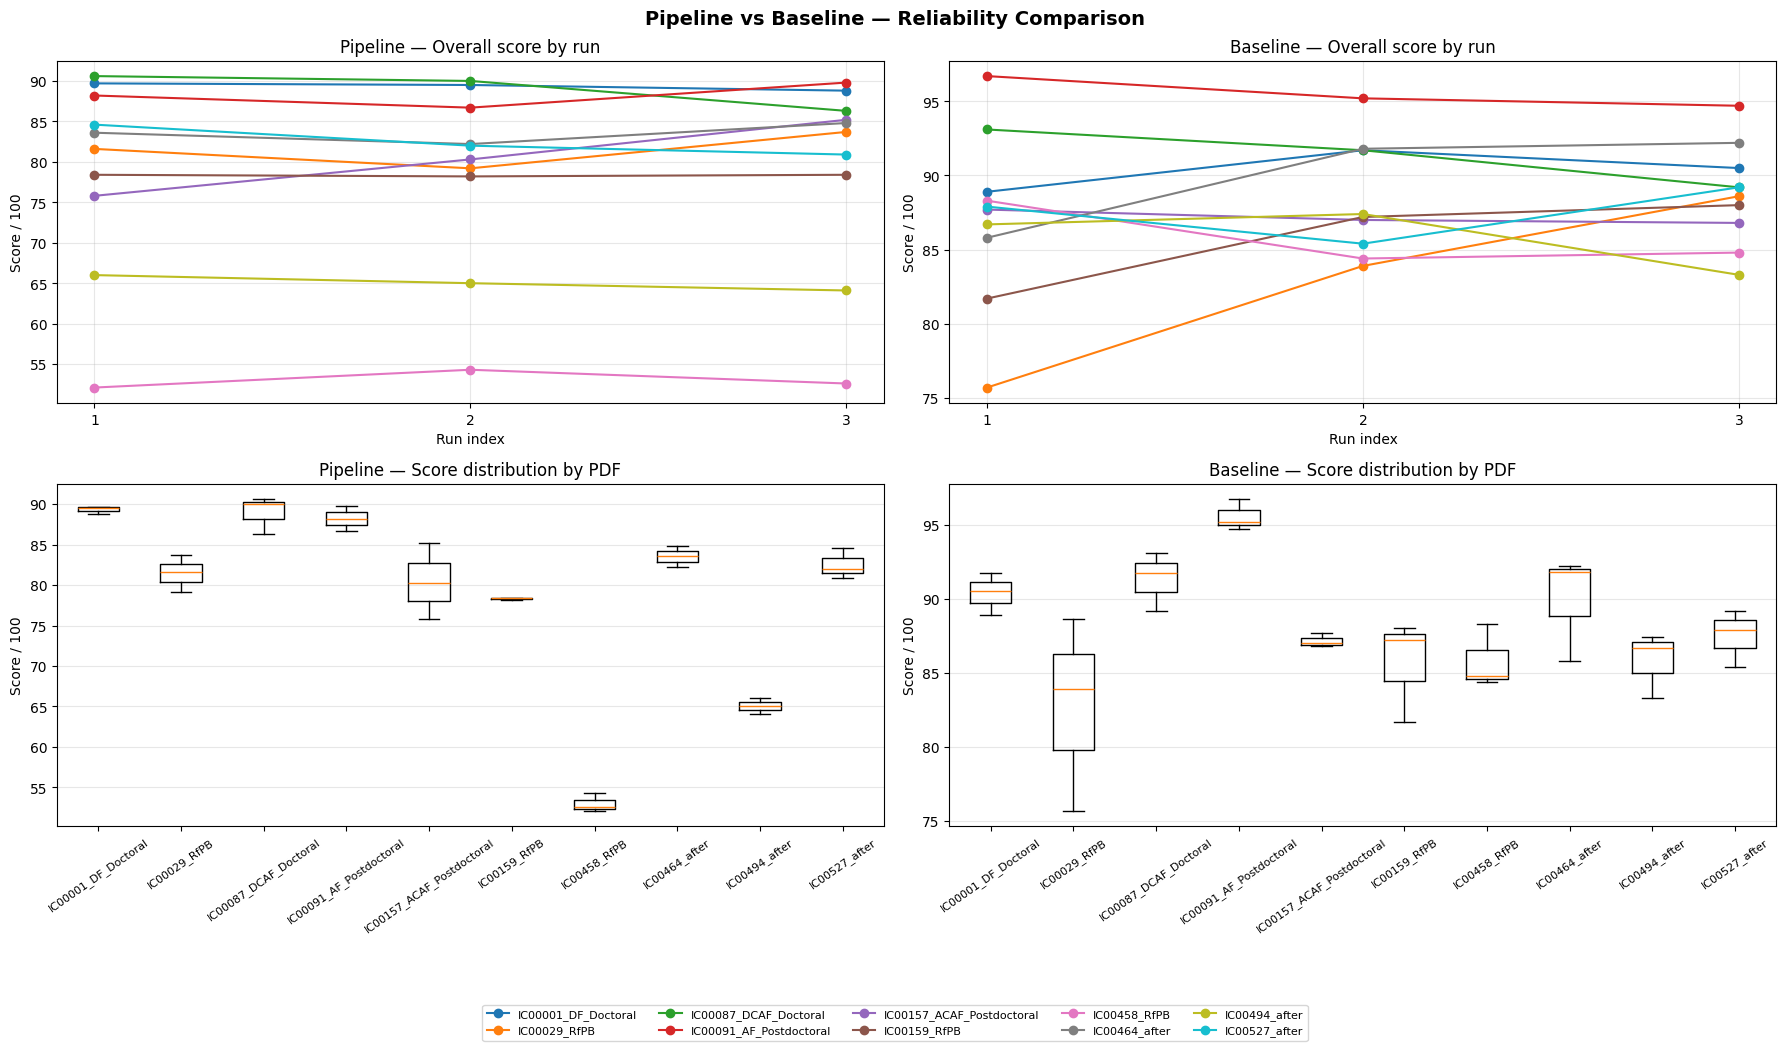

Saved: d:\msc_AI\SWE_group_project\nlp_grant_coursework\experiments\results\reliability_results\pipeline_vs_baseline_reliability.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path(RESULTS_DIR) if 'RESULTS_DIR' in dir() else Path(
    __file__).parent / 'results' / 'reliability_results'

# ── Load data ─────────────────────────────────────────────────────────────────
_pipe_csv = RESULTS_DIR / 'same_pdf_distribution_runs_20260424_194005.csv'
_base_csv = RESULTS_DIR / 'baseline_results.csv'
pipe_df = pd.read_csv(_pipe_csv)
base_df = pd.read_csv(_base_csv)

SECTION_COLS = [
    'general_score_100', 'proposed_research_score_100',
    'training_development_score_100', 'sites_support_score_100',
    'wpcc_score_100', 'application_form_score_100',
]

# ── Stability comparison table ────────────────────────────────────────────────
def _stability(df: pd.DataFrame, tag: str) -> pd.DataFrame:
    grp = df.groupby('pdf_name')['overall_score_100']
    return pd.DataFrame({
        f'{tag}_mean': grp.mean().round(2),
        f'{tag}_std':  grp.std(ddof=1).round(3),
        f'{tag}_range': (grp.max() - grp.min()).round(2),
    })

pipe_stab = _stability(pipe_df, 'pipeline')
base_stab = _stability(base_df, 'baseline')
stability_table = pipe_stab.join(base_stab).reset_index()
stability_table['std_diff'] = (
    stability_table['pipeline_std'] - stability_table['baseline_std']
).round(3)
stability_table['more_stable'] = stability_table['std_diff'].apply(
    lambda x: 'pipeline' if x < 0 else ('baseline' if x > 0 else 'tie')
)

display(stability_table[[
    'pdf_name',
    'pipeline_mean', 'pipeline_std', 'pipeline_range',
    'baseline_mean',  'baseline_std',  'baseline_range',
    'std_diff', 'more_stable',
]])

# ── Combined 2x2 figure ───────────────────────────────────────────────────────
pdf_names = sorted(pipe_df['pdf_name'].unique())
short = [n.replace('.pdf', '') for n in pdf_names]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Pipeline vs Baseline — Reliability Comparison', fontsize=14, fontweight='bold')

# ── [0,0] Pipeline: score by run ──────────────────────────────────────────────
ax = axes[0, 0]
for pdf_name, pdf_df in pipe_df.groupby('pdf_name'):
    ax.plot(pdf_df['run_idx'], pdf_df['overall_score_100'], marker='o',
            label=pdf_name.replace('.pdf', ''))
ax.set_title('Pipeline — Overall score by run')
ax.set_xlabel('Run index')
ax.set_ylabel('Score / 100')
ax.set_xticks([1, 2, 3])
ax.grid(alpha=0.3)

# ── [0,1] Baseline: score by run ──────────────────────────────────────────────
ax = axes[0, 1]
for pdf_name, pdf_df in base_df.groupby('pdf_name'):
    ax.plot(pdf_df['run_idx'], pdf_df['overall_score_100'], marker='o',
            label=pdf_name.replace('.pdf', ''))
ax.set_title('Baseline — Overall score by run')
ax.set_xlabel('Run index')
ax.set_ylabel('Score / 100')
ax.set_xticks([1, 2, 3])
ax.grid(alpha=0.3)

# ── [1,0] Pipeline: boxplot by PDF ───────────────────────────────────────────
ax = axes[1, 0]
pipe_grouped = [
    pipe_df.loc[pipe_df['pdf_name'] == n, 'overall_score_100'].tolist()
    for n in pdf_names
]
ax.boxplot(pipe_grouped, tick_labels=short)
ax.set_title('Pipeline — Score distribution by PDF')
ax.set_ylabel('Score / 100')
ax.tick_params(axis='x', labelrotation=35, labelsize=8)
ax.grid(axis='y', alpha=0.3)

# ── [1,1] Baseline: boxplot by PDF ───────────────────────────────────────────
ax = axes[1, 1]
base_grouped = [
    base_df.loc[base_df['pdf_name'] == n, 'overall_score_100'].tolist()
    for n in pdf_names
]
ax.boxplot(base_grouped, tick_labels=short)
ax.set_title('Baseline — Score distribution by PDF')
ax.set_ylabel('Score / 100')
ax.tick_params(axis='x', labelrotation=35, labelsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Shared legend below the top row ──────────────────────────────────────────
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.01),
    ncol=min(5, len(pdf_names)),
    fontsize=8,
    frameon=True,
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
out_fig = RESULTS_DIR / 'pipeline_vs_baseline_reliability.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')
